# STalign parity: `merfish-merfish-alignment.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-merfish-alignment.ipynb).

Status: `compared`. 


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 9.841786075461633e-06,
  "L relative L2": 0.0,
  "df1[Unnamed: 0] label disagreement": 0.0,
  "df1[Unnamed: 0] label set jaccard": 1.0,
  "df1[Unnamed: 0] labels only squidpy": 0.0,
  "df1[Unnamed: 0] labels only upstream": 0.0,
  "df1[center_x] median abs delta": 0.0,
  "df1[center_y] median abs delta": 0.0,
  "df1[max_x] median abs delta": 0.0,
  "df1[max_y] median abs delta": 0.0,
  "df1[min_x] median abs delta": 0.0,
  "df1[min_y] median abs delta": 0.0,
  "df1[volume] median abs delta": 0.0,
  "df2[Unnamed: 0] label disagreement": 0.0,
  "df2[Unnamed: 0] label set jaccard": 1.0,
  "df2[Unnamed: 0] labels only squidpy": 0.0,
  "df2[Unnamed: 0] labels only upstream": 0.0,
  "df2[center_x] median abs delta": 0.0,
  "df2[center_y] median abs delta": 0.0,
  "df2[max_x] median abs delta": 0.0,
  "df2[max_y] median abs delta": 0.0,
  "df2[min_x] median abs delta": 0.0,
  "df2[min_y] median abs delta": 0.0,
  "df2[volume] median abs delta": 0.0,
  "df3 relative L2": 1

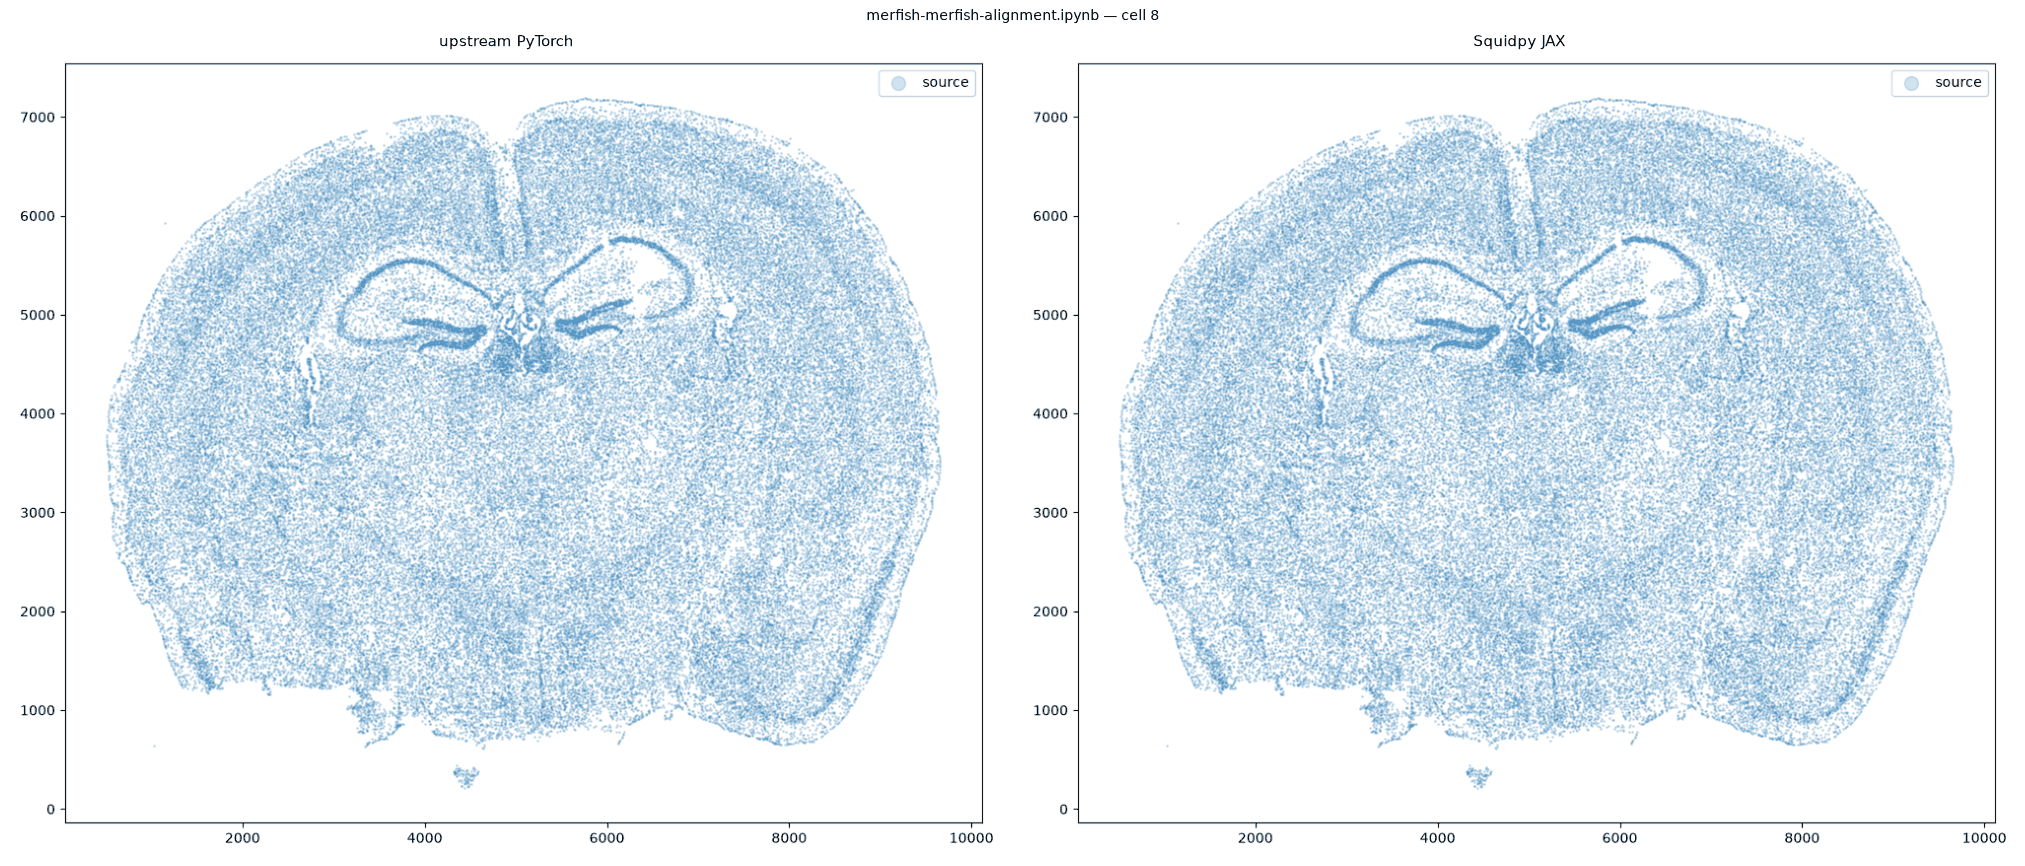

In [2]:
# get cell centroid coordinates
xI = np.array(df1['center_x'])
yI = np.array(df1['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2, label='source')
ax.legend(markerscale = 10)

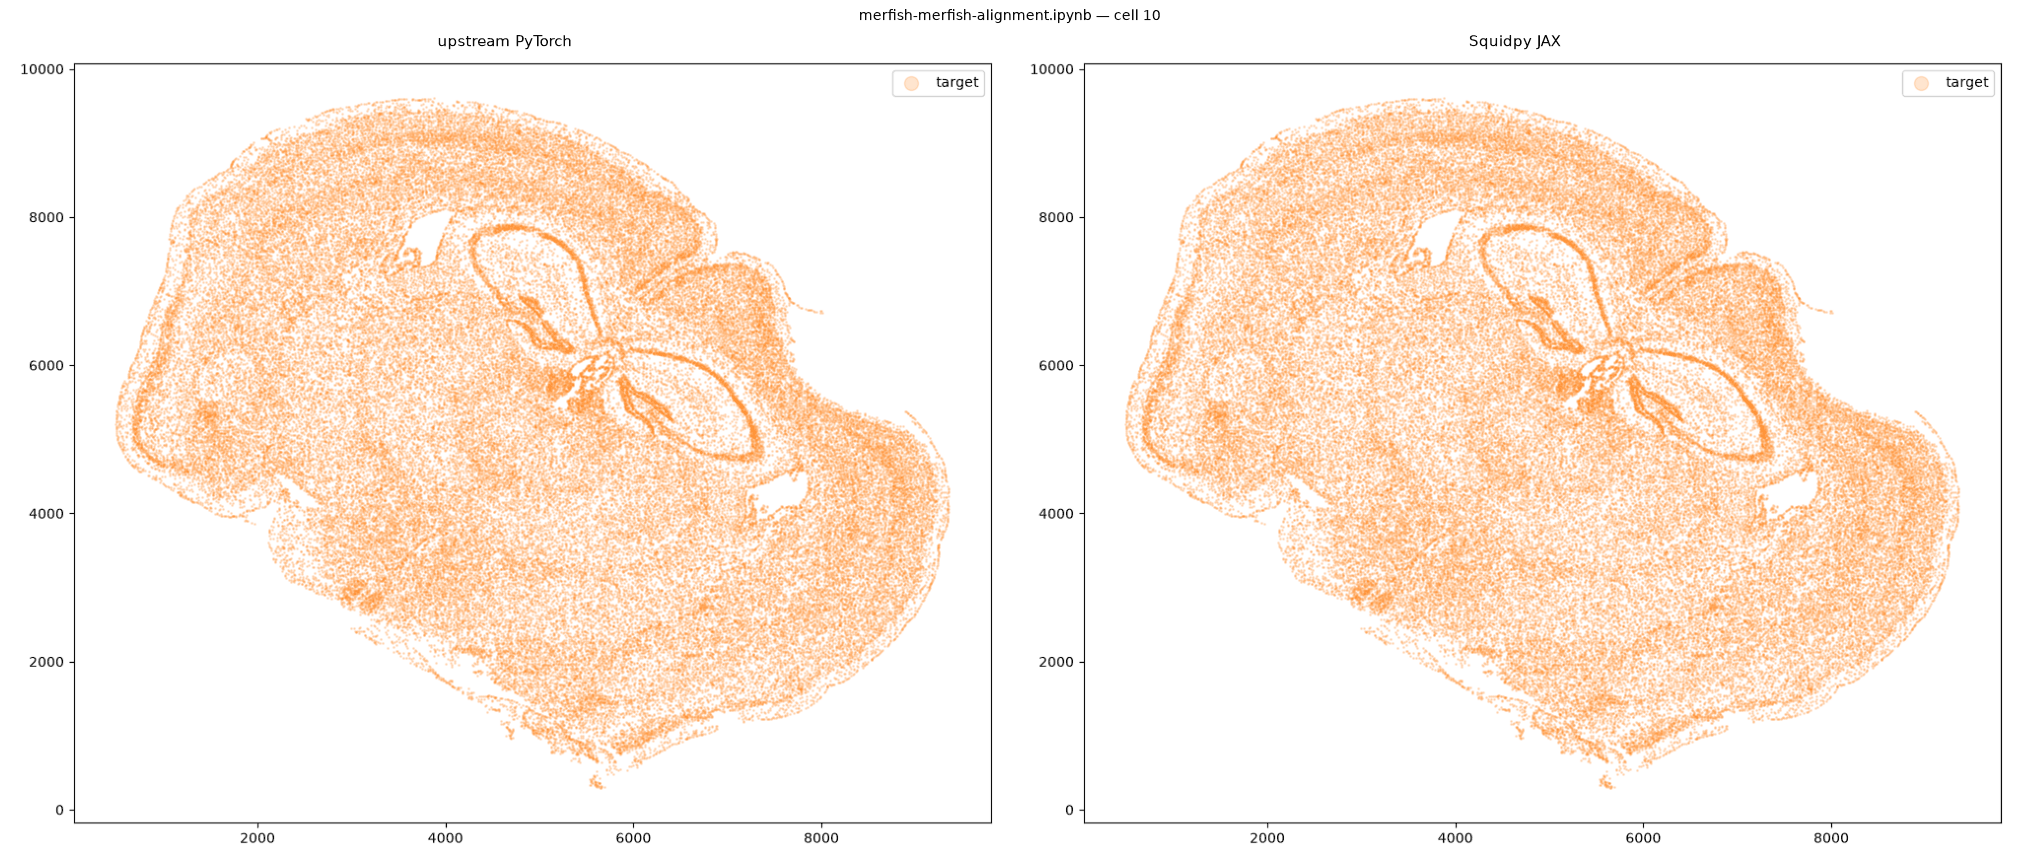

In [3]:
# Single cell data 2
# read in data
fname = '../merfish_data/datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate2_cell_metadata_S2R2.csv.gz'

df2 = pd.read_csv(fname)

# get cell centroids
xJ = np.array(df2['center_x'])
yJ = np.array(df2['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e', label='target')
ax.legend(markerscale = 10)

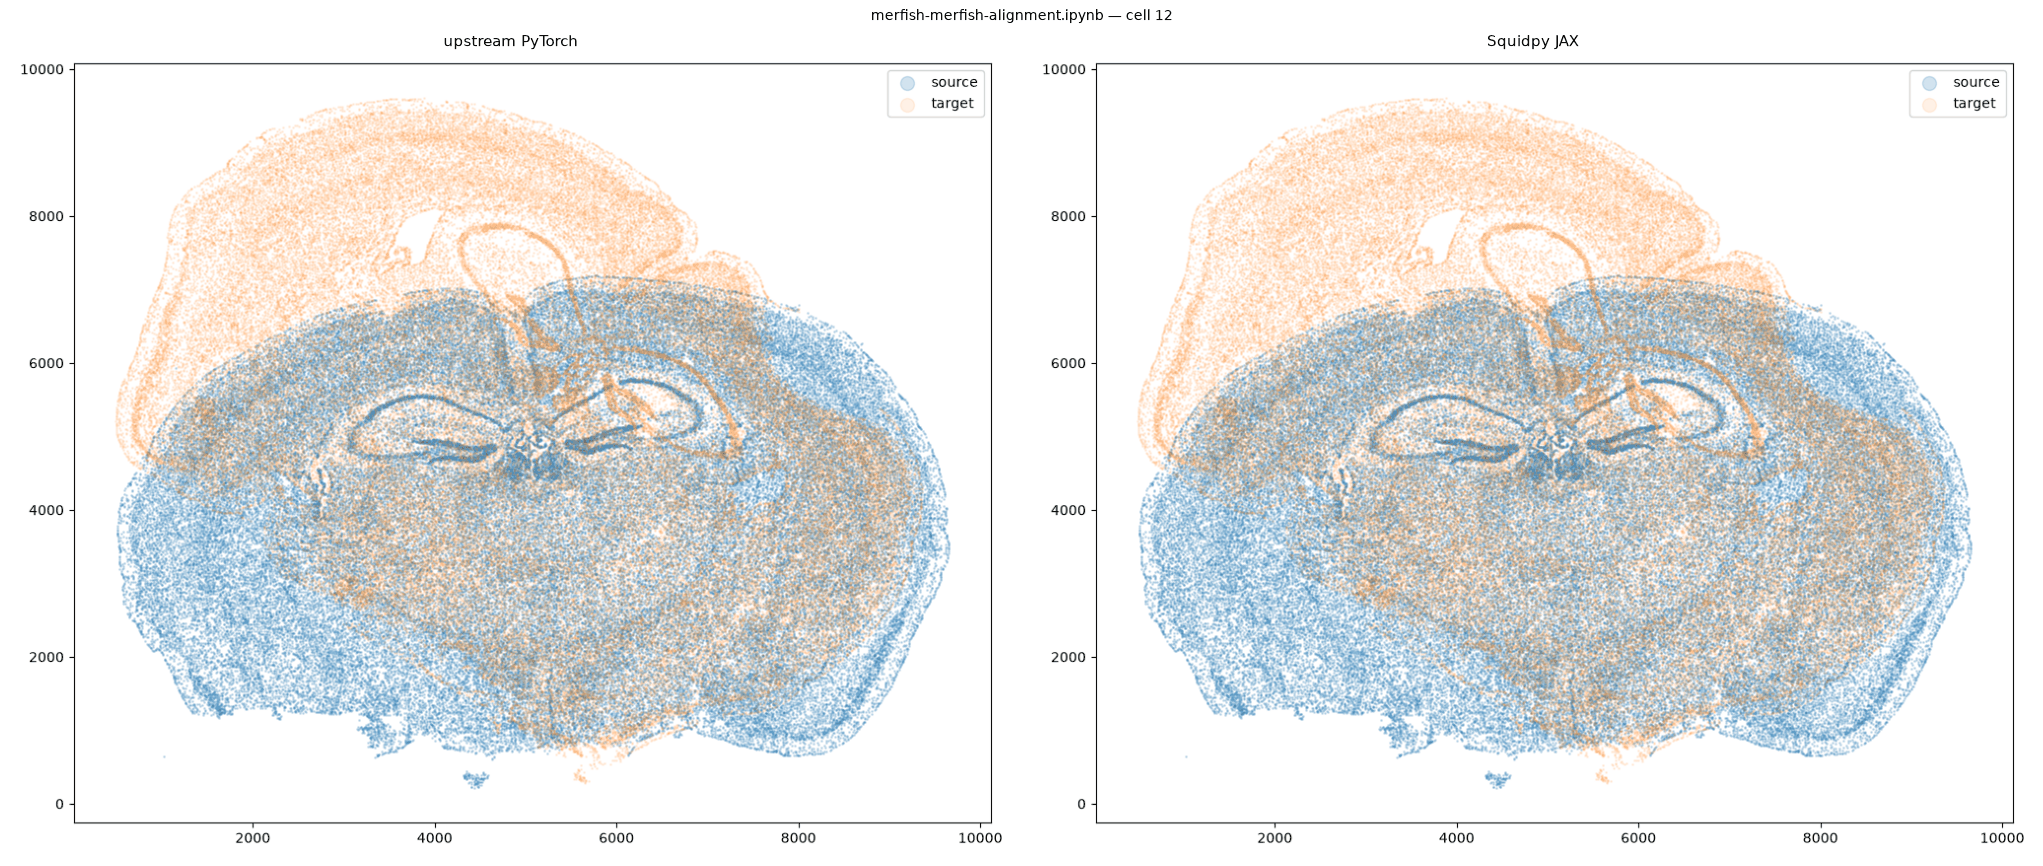

In [4]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2, label='source')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label= 'target')
ax.legend(markerscale = 10)

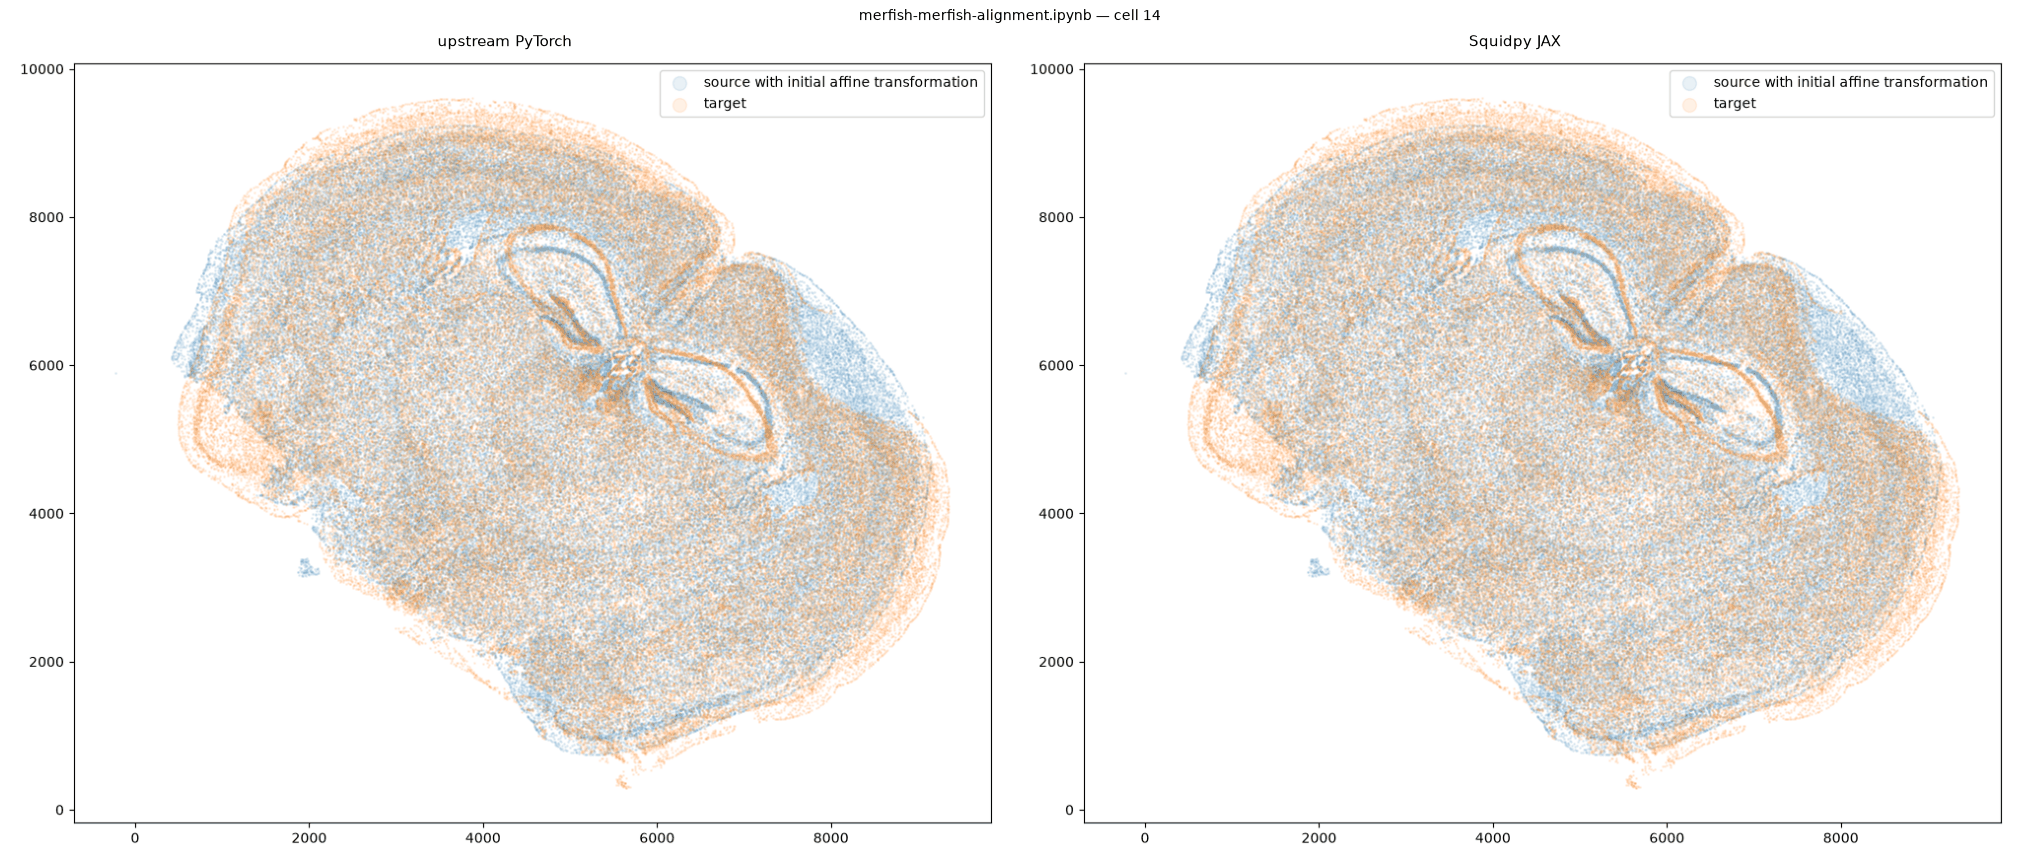

In [5]:
theta_deg = 45
theta0 = (np.pi/180)*-theta_deg

#rotation matrix 
#rotates about the origin
L = np.array([[np.cos(theta0),-np.sin(theta0)],
              [np.sin(theta0),np.cos(theta0)]])

source_L = np.matmul(L , np.array([xI, yI]))
xI_L = source_L[0]
yI_L = source_L[1]

#translation matrix
#effectively makes the rotation about the centroid of I (i.e the means of xI and yI]) 
#and also moves the centroid of I to the centroid of J
T = np.array([ np.mean(xI)- np.cos(theta0)*np.mean(xI) +np.sin(theta0)*np.mean(yI) - (np.mean(xI)-np.mean(xJ)),
              np.mean(yI)- np.sin(theta0)*np.mean(xI) -np.cos(theta0)*np.mean(yI) - (np.mean(yI)-np.mean(yJ))])

xI_L_T = xI_L + T[0]
yI_L_T = yI_L + T[1]


fig,ax = plt.subplots()
ax.scatter(xI_L_T,yI_L_T,s=1,alpha=0.1, label='source with initial affine transformation')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label = 'target')
ax.legend(markerscale = 10)

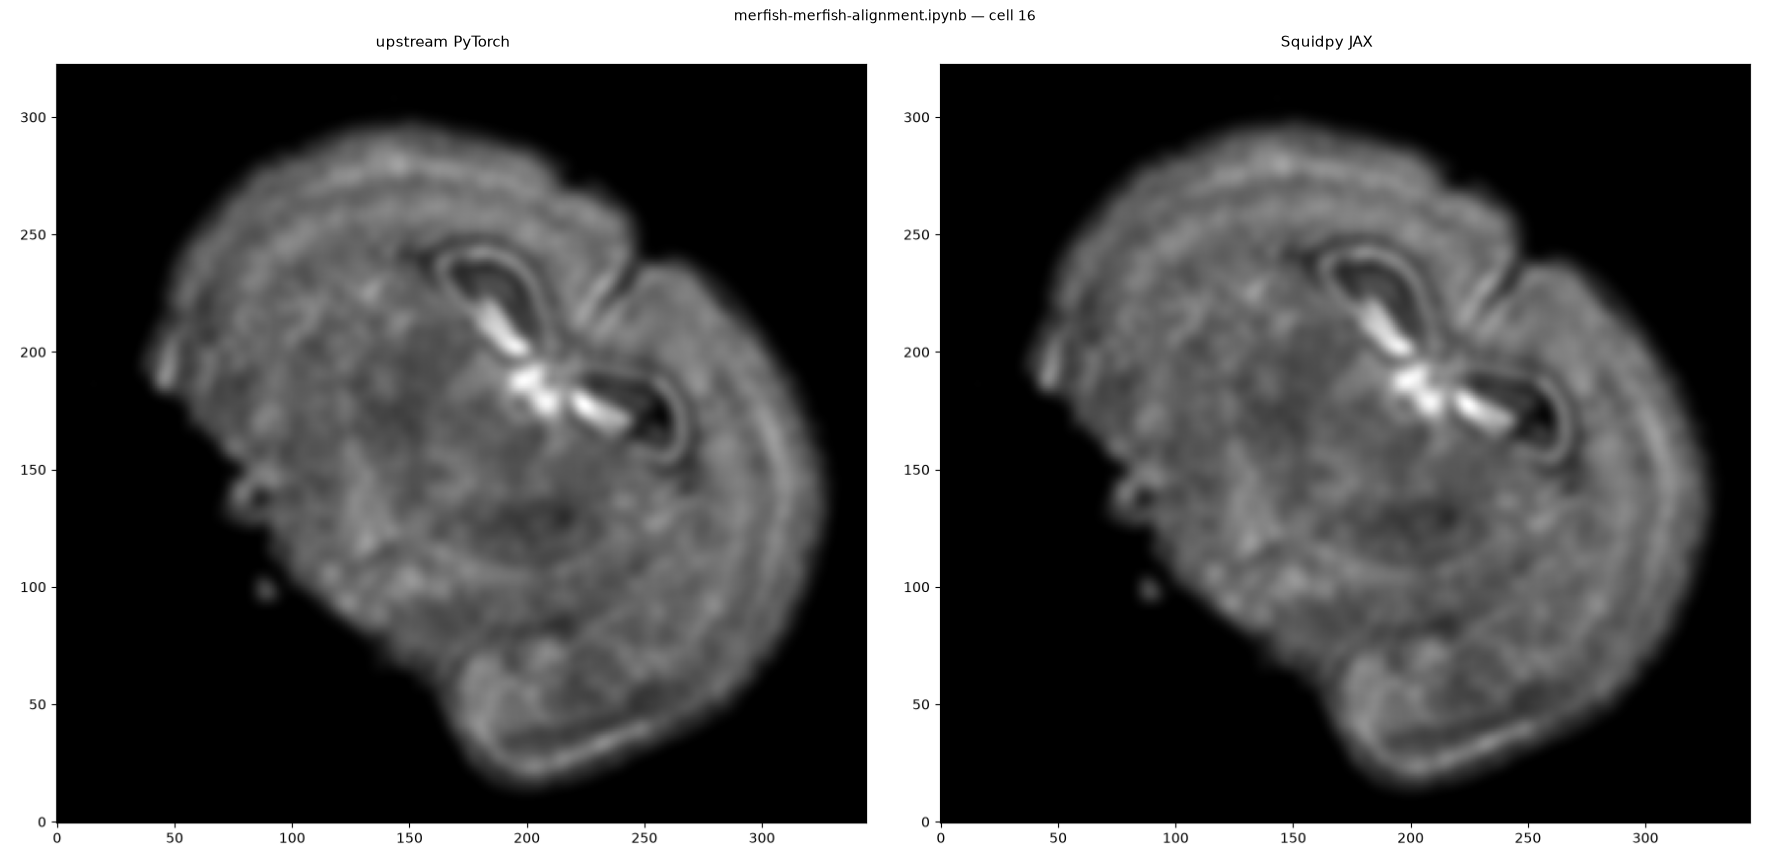

In [6]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI_L_T,yI_L_T,dx=30,blur=1.5)

# plot
ax = fig.axes[0]
ax.invert_yaxis()

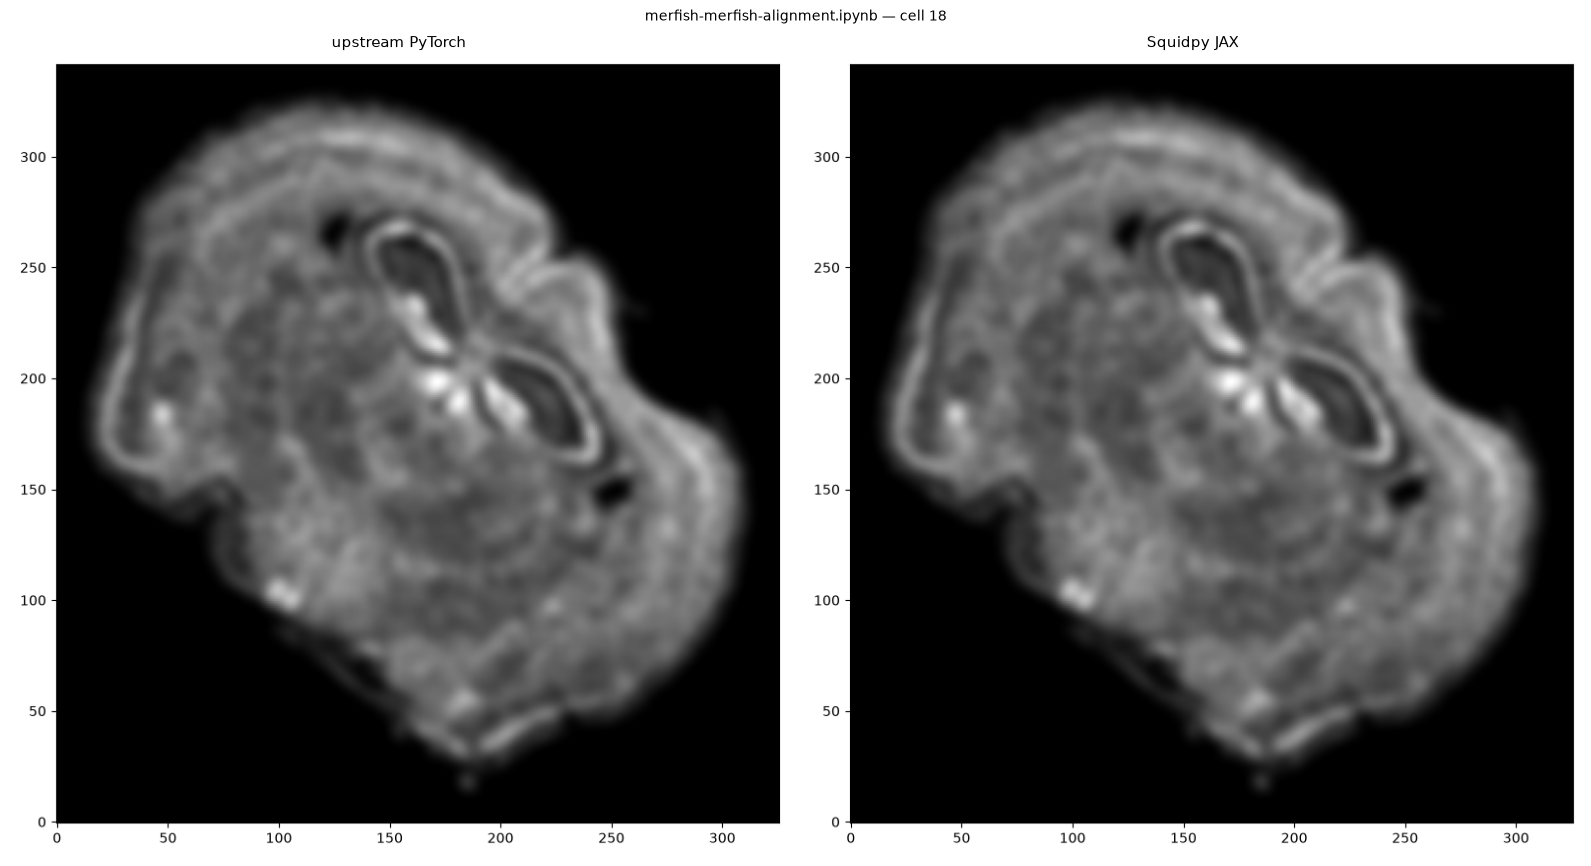

In [7]:
# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=30, blur=1.5)
ax = fig.axes[0]
ax.invert_yaxis()

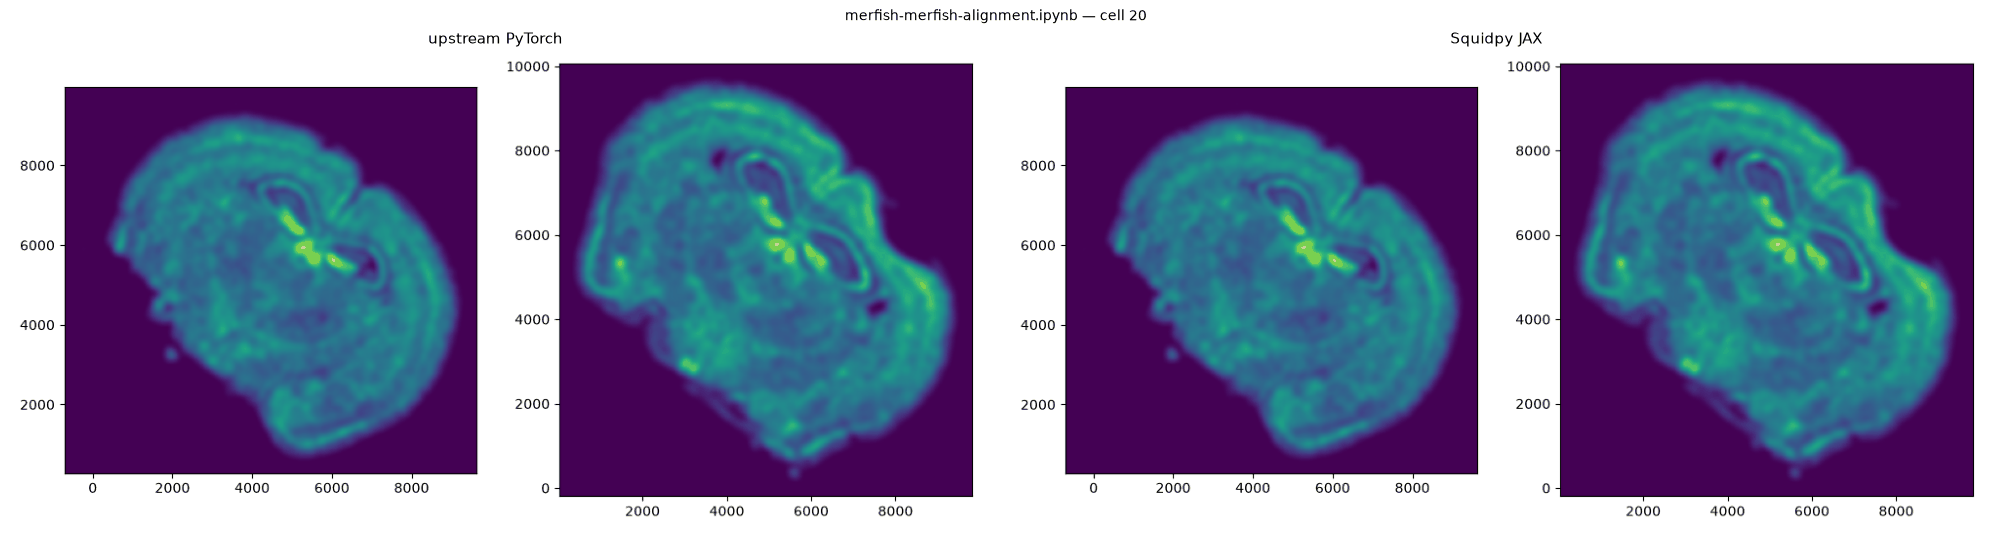

In [8]:
# get extent of images
extentI = STalign.extent_from_x((YI,XI))
extentJ = STalign.extent_from_x((YJ,XJ))

# plot rasterized images
fig,ax = plt.subplots(1,2)
ax[0].imshow(I[0], extent=extentI) 
ax[1].imshow(J[0], extent=extentJ)
ax[0].invert_yaxis()
ax[1].invert_yaxis()

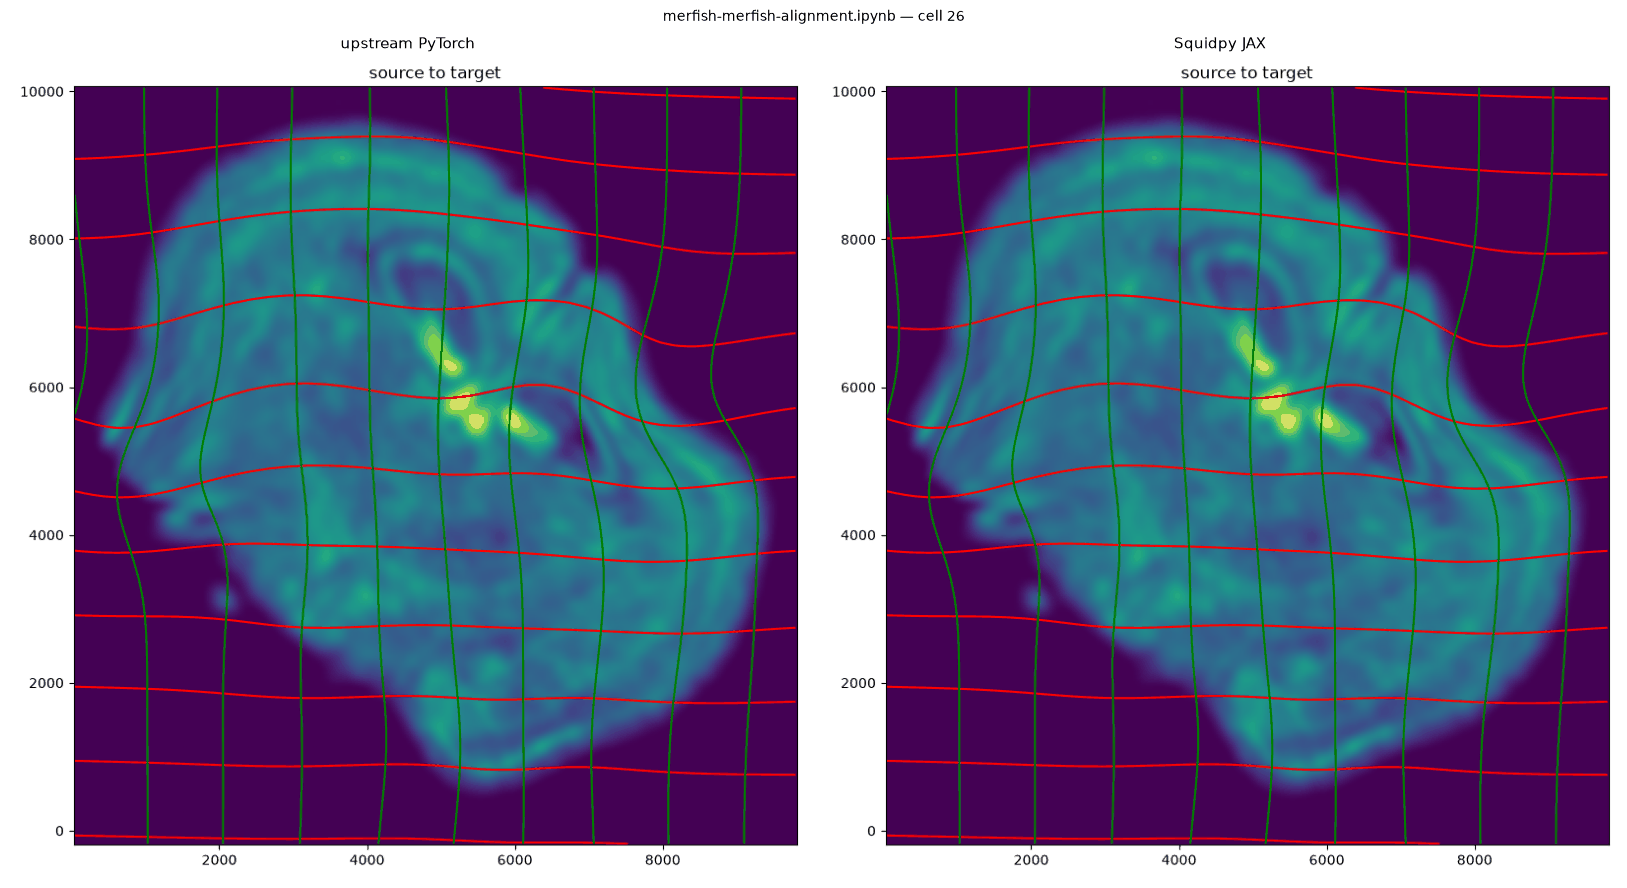

In [9]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],I,[YJ,XJ])

#switch tensor from cuda to cpu for plotting with numpy
if phii.is_cuda:
    phii = phii.cpu()
if phiI.is_cuda:
    phiI = phiI.cpu()

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XJ,YJ,phii[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XJ,YJ,phii[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('source to target')
ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extentJ)
ax.invert_yaxis()

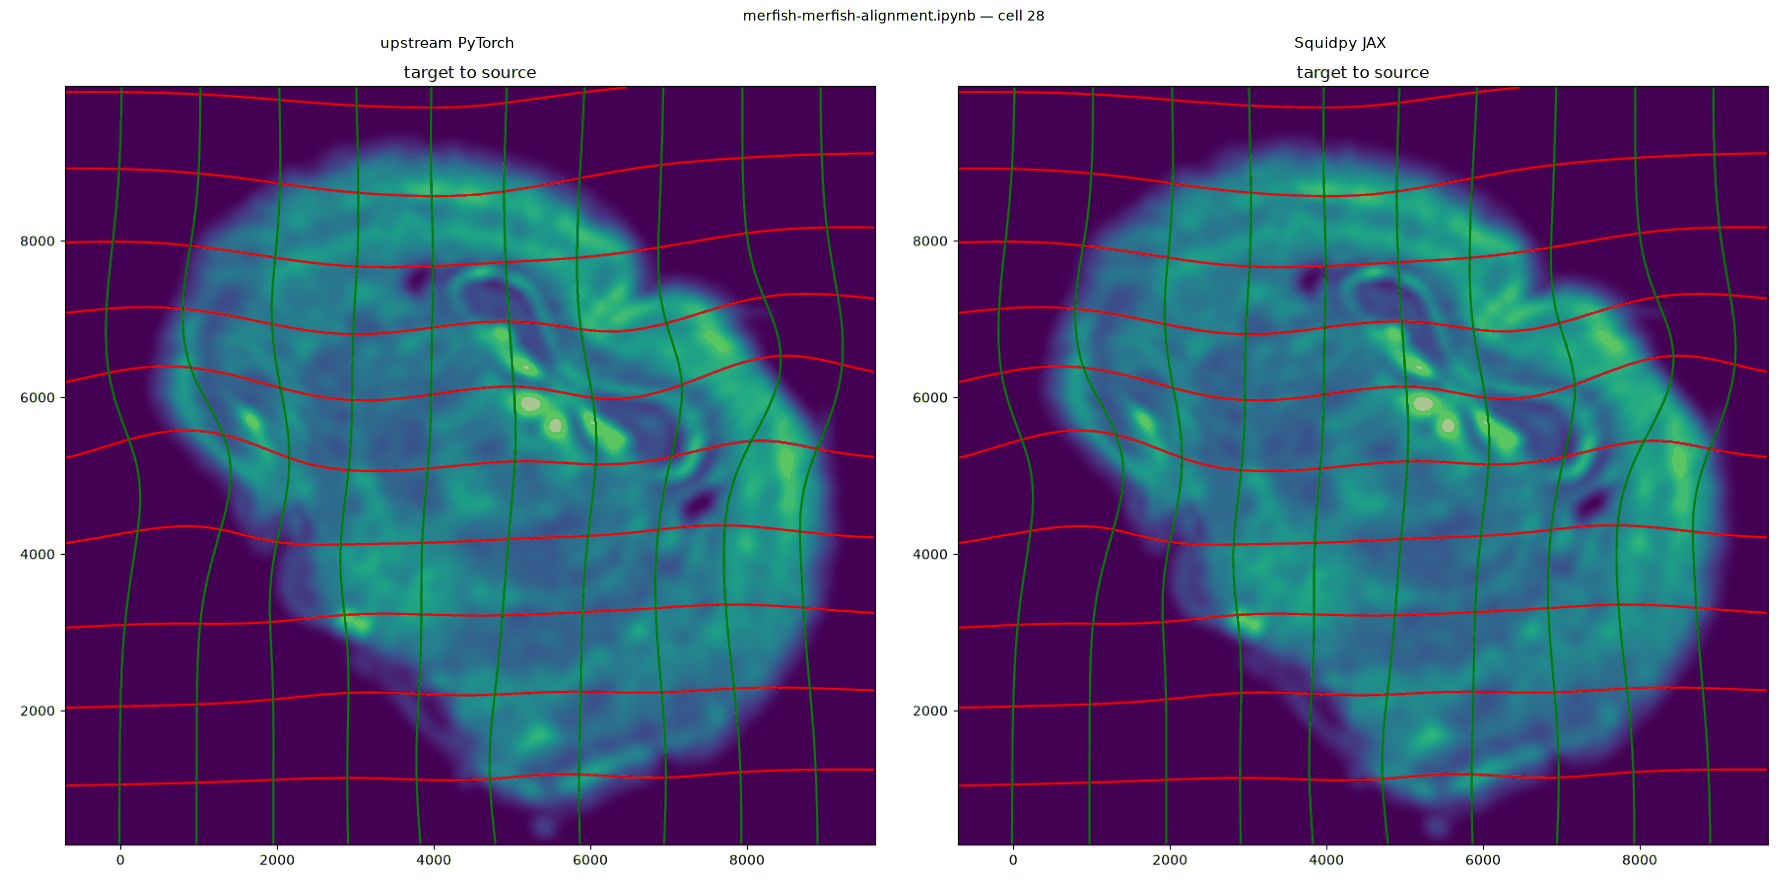

In [10]:
# transform is invertible
phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],J,[YI,XI])

#switch tensor from cuda to cpu for plotting with numpy
if phi.is_cuda:
    phi = phi.cpu()
if phiiJ.is_cuda:
    phiiJ = phiiJ.cpu()

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('target to source')
ax.imshow(phiiJ.permute(1,2,0)/torch.max(phiiJ),extent=extentI)
ax.invert_yaxis()

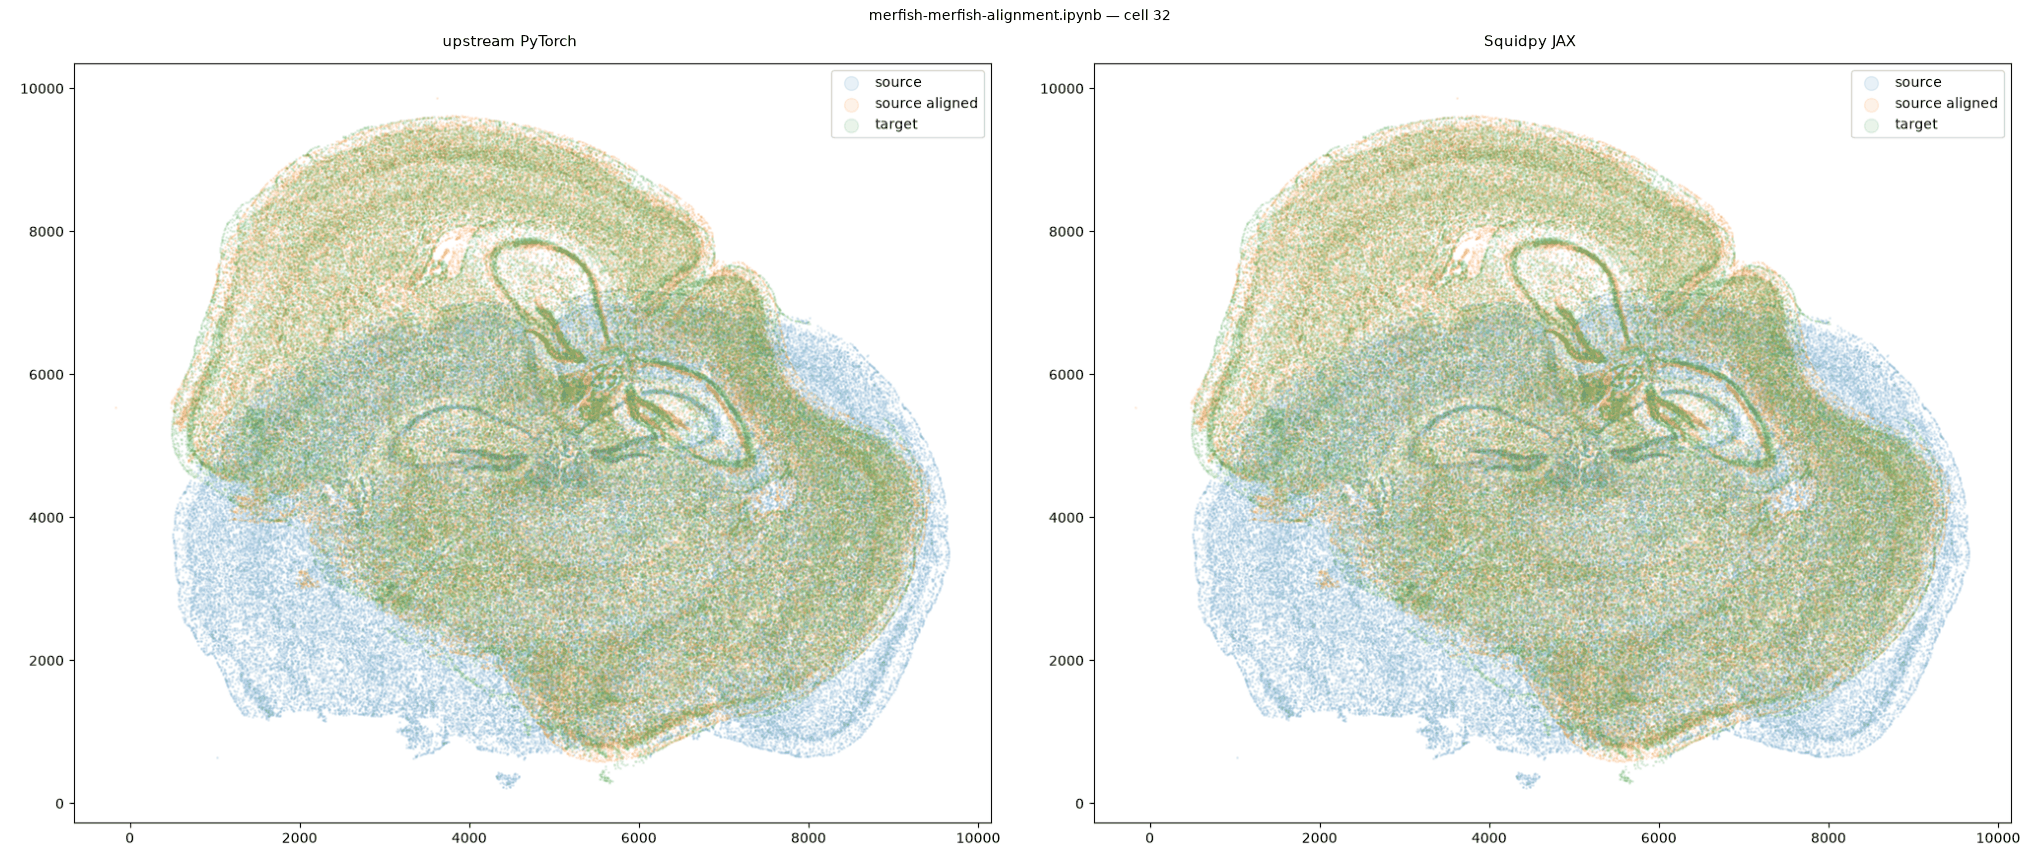

In [11]:
# plot results
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.1, label='source')
ax.scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.1, label = 'source aligned')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label='target')
ax.legend(markerscale = 10)

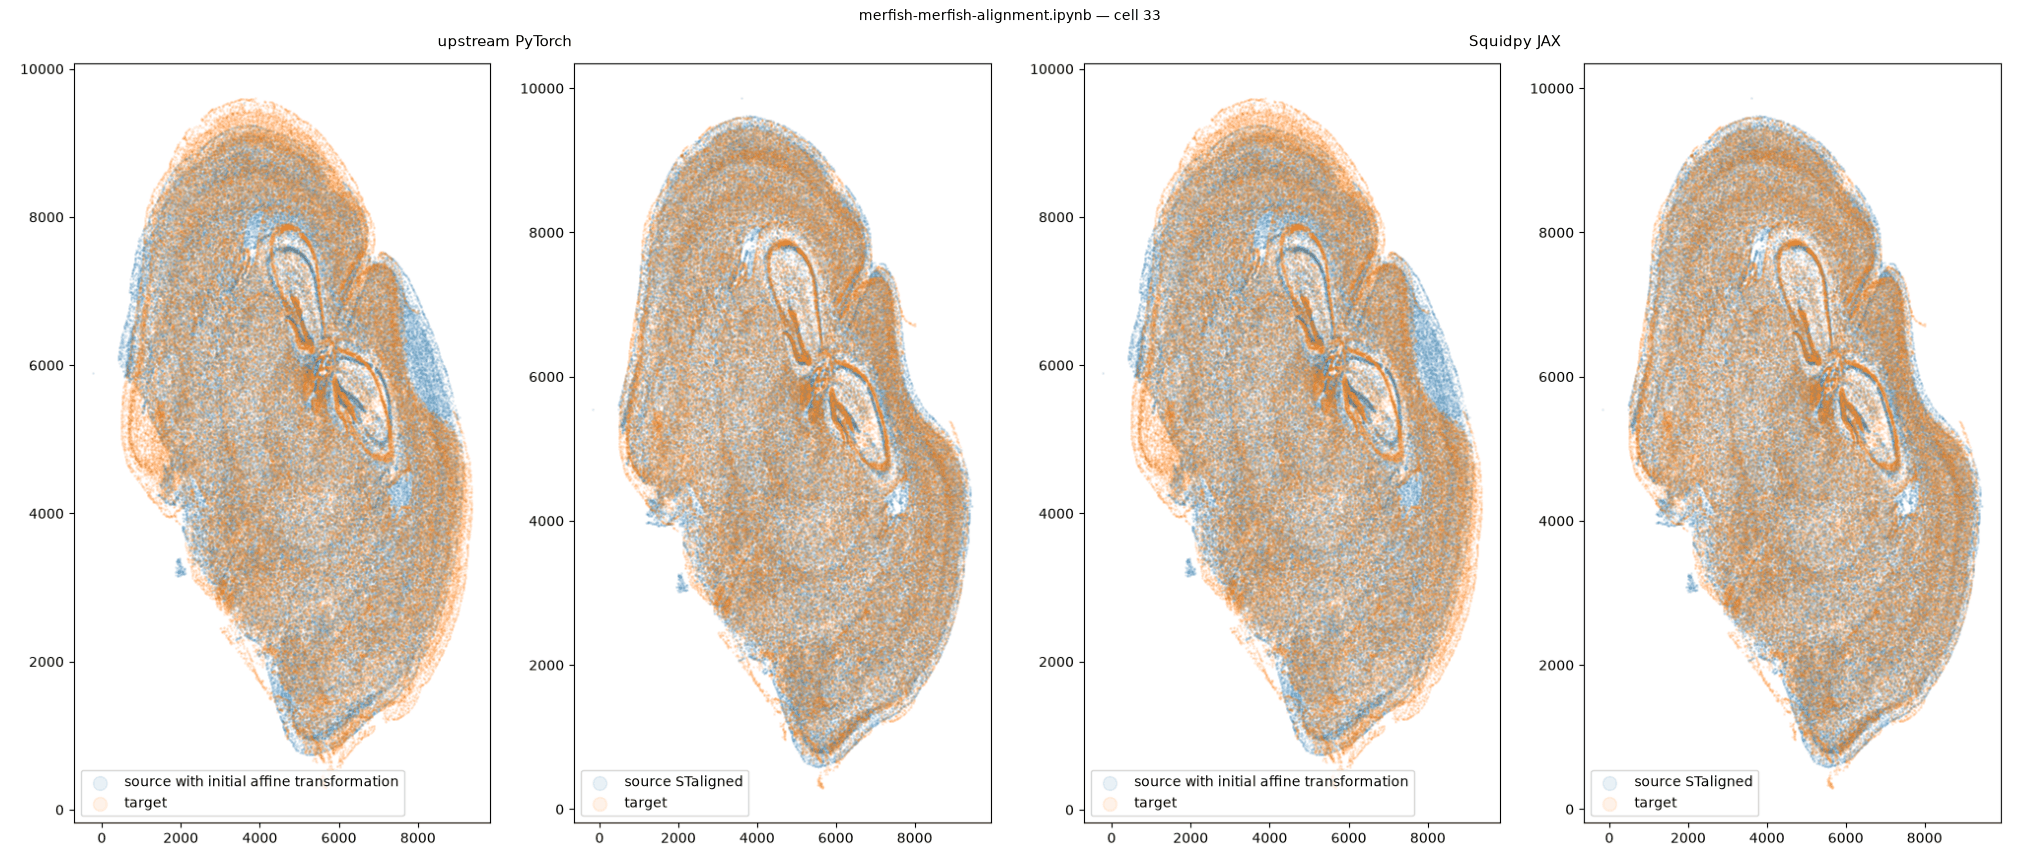

In [12]:
fig,ax = plt.subplots(1,2)
ax[0].scatter(xI_L_T,yI_L_T,s=1,alpha=0.1, label='source with initial affine transformation')
ax[0].scatter(xJ,yJ,s=1,alpha=0.1, label='target')
ax[1].scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.1, label = 'source STaligned') 
ax[1].scatter(xJ,yJ,s=1,alpha=0.1, label='target')
ax[0].legend(markerscale = 10, loc = 'lower left')
ax[1].legend(markerscale = 10, loc = 'lower left')

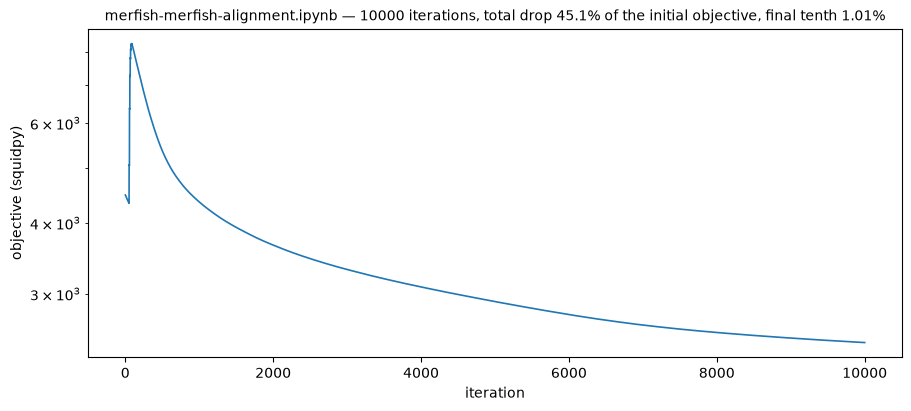

In [13]:
# upstream vs squidpy — figure 12
